# Clustering
## 1. run clustering script

In [18]:
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

In [19]:
%run train_Kmeans.py

  CLUSTERING - Kmeans with PCA (random_state = 42)
  PCA kept 178 components for 90% variance
--- Selecting Kmeans ---
 -- K=3   | inertia=    157571.4 | sil=0.0989
 -- K=4   | inertia=    151069.7 | sil=0.0868
 -- K=5   | inertia=    146830.9 | sil=0.0803
 -- K=6   | inertia=    143661.4 | sil=0.0727
 -- K=7   | inertia=    141153.9 | sil=0.0528
 -- K=8   | inertia=    139265.4 | sil=0.0520
 -- K=9   | inertia=    137602.5 | sil=0.0473
 -- K=10  | inertia=    136081.0 | sil=0.0448
 -- K=11  | inertia=    134869.5 | sil=0.0474
 -- K=12  | inertia=    133695.4 | sil=0.0428
 -- K=13  | inertia=    132597.4 | sil=0.0422
 -- K=14  | inertia=    131768.4 | sil=0.0394
 -- K=15  | inertia=    130776.8 | sil=0.0396
 -- K=16  | inertia=    130085.9 | sil=0.0419
 -- K=17  | inertia=    129246.3 | sil=0.0421
 -- K=18  | inertia=    128629.9 | sil=0.0381
 -- K=19  | inertia=    127945.4 | sil=0.0406
 -- K=20  | inertia=    127348.9 | sil=0.0415
--- Chosen K=3 ---
  cluster 0: train=5781,  test=148

## 2. Plots

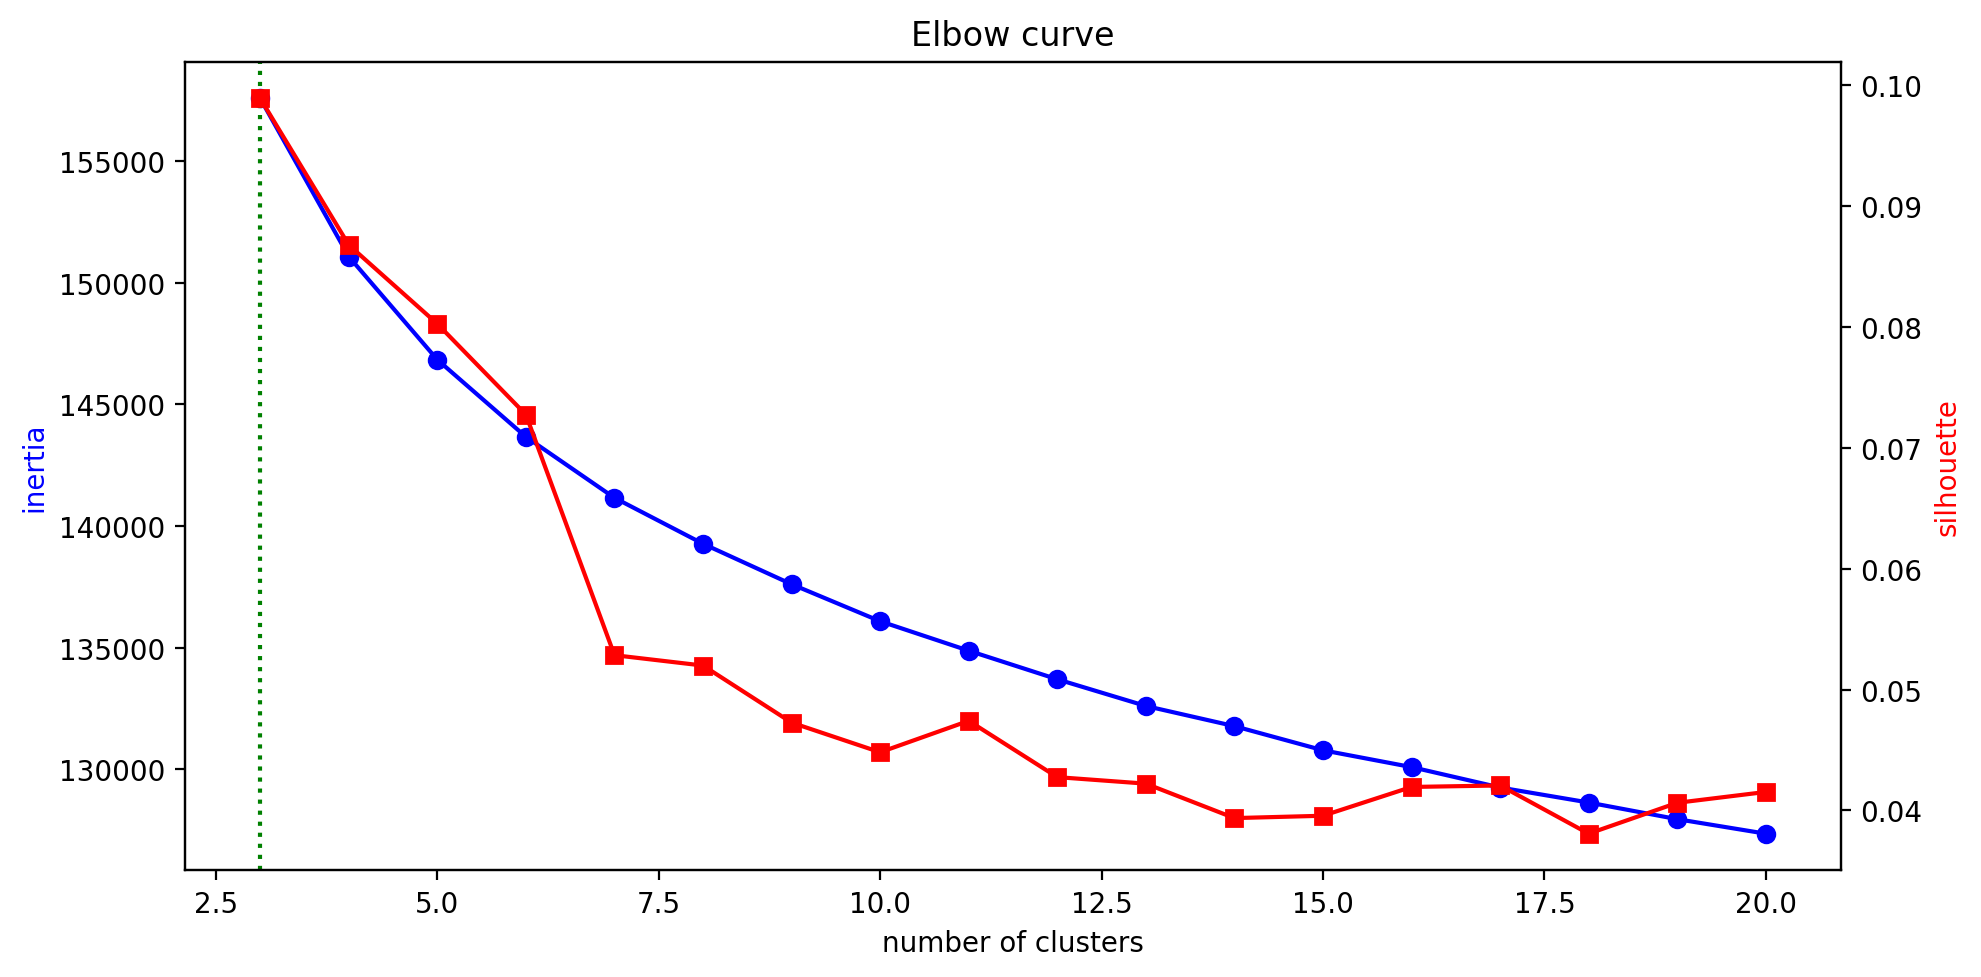

In [20]:
from IPython.display import Image, display
display(Image(filename='results/Kmeans/K_selection.png'))

## 3. Feed RF with Clusters

In [21]:
%run train_rf_with_Kmeans

  TRAIN - Random Forest with Kmeans features, (Random state=42, K=3)

  --- Baseline +Clusters  (X_train: (14578, 684)) ---
     Test Accuracy : 0.5986
     Test F1-Score : 0.6560
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          787       911   FP rate = 0.5365
        True:Hit           552      1395   FN rate = 0.2835
  Plain RF without clusters: Acc - 0.6041 F1 - 0.6565
  RF with clusters: ACC - 0.5986 F1 - 0.6560
  Affect of clusters ACC - -0.0055 F1 - -0.0005

  --- Advanced +Clusters  (X_train: (14578, 693)) ---
     Test Accuracy : 0.6134
     Test F1-Score : 0.6643
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          842       856   FP rate = 0.5041
        True:Hit           553      1394   FN rate = 0.2840
  Plain RF without clusters: Acc - 0.6239 F1 - 0.6753
  RF with clusters: ACC - 0.6134 F1 - 0.6643
  Affect of clusters ACC - -0.0104 F1 - -0.0111

  >> Δ (Advanced − Baseline):  Acc +0.0148

## 4. Metrics summery

In [22]:
import json
from src import load_metrics

with open ("results/Kmeans/clustering_summery.json", encoding="utf-8") as f:
    summery = json.load(f)
    print(f"Chosen K: {summery['chosen_k']}")
    print(f"PCA components: {summery['space']['pca_components']}")
    for c in summery['clusters']:
        print(f"  cluster {c['cluster']}: train={c['train_size']>6} test={c['test_size']>5}")

metrics = load_metrics("RF_Kmeans")
print()
for ds, vals in metrics["datasets"].items():
    print(f"{ds:>9} + clusters: accuracy={vals['accuracy']:.4f} F1 = {vals['f1']:.4f}")
for ds, eff in metrics["extras"]["cluster_columns_effect"].items():
    print(f"{ds:>9} + clusters effect: accuracy {eff['accuracy']:+.4f} F1 = {eff['f1']:.4f}")

Chosen K: 3
PCA components: 178
  cluster 0: train=True test=True
  cluster 1: train=True test=True
  cluster 2: train=True test=True

 Baseline + clusters: accuracy=0.5986 F1 = 0.6560
 Advanced + clusters: accuracy=0.6134 F1 = 0.6643
 Baseline + clusters effect: accuracy -0.0055 F1 = -0.0005
 Advanced + clusters effect: accuracy -0.0104 F1 = -0.0111
